<a href="https://colab.research.google.com/github/bingxiaochen/ST554/blob/main/ST_554_HW5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Bing Chen

ST 554 HW5

2/27/2026

## Part I: Concepts:

1. One example of big data I have encountered is in a research project where I gather and analyze historical public datasets. The project involves compiling large amounts of data collected over many years, reflects volume. The dataset spans long time periods and may be updated over time, reflecting velocity in terms of ongoing data accumulation. The data is also significant variety, since the data come from multiple public sources with different formats and structures, requiring massive cleaning and merging. The data show variability because patterns may change across time or groups, which affects how the analysis must be conducted. Finally, veracity is shown as the data include missing values or inconsistencies.

2.
 - Create: Add a new table to store custom analytics results
 - Read: extract career home run totals for a particular player
 - Update: If there's error, we'll update with the correct value
 - Delete: remove duplicate records

 3. The HAVING clause filters results after a GROUP BY operation, while the WHERE clause filters rows before grouping occurs.



## Part II： Simulation of a Sampling Distribution

4. We want to use simulations to explore the sampling distribution of the sample slope from an SLR model. We'll use linear model: $Y_i = \beta_0 + \beta_1x_i + E_i$, where the E_i are assumed to be indendent and identically distributed from a Normal distribution with mean 0 and variance 1.

Set up:

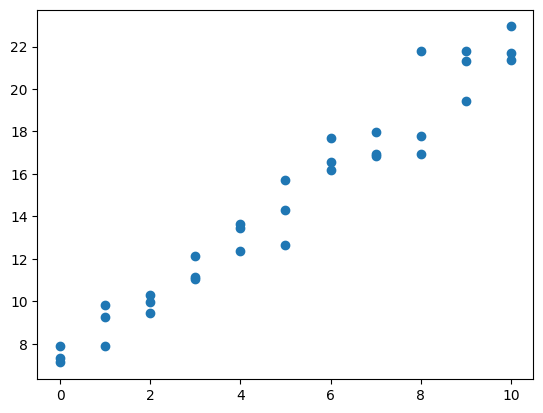

In [1]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng

rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5

# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33

#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y)
plt.show()

Now we'll use `sklearn` to obtain the estimate for the slope.

First, check the shape of the data. And reshape the data if needed.


In [7]:
print(y.shape)

print(y.reshape(-1,1).shape)

print(x.shape)

print(x.reshape(-1,1).shape)

(33,)
(33, 1)
(33,)
(33, 1)


Let's import the `sklearn` module and fit the model.

In [18]:
from sklearn import linear_model

reg = linear_model.LinearRegression()
reg.fit(x.reshape(-1,1), y)

intercept = reg.intercept_
slope = reg.coef_

intercept, slope

(np.float64(6.792866228405875), array([1.56569763]))

Now, start the simulation process, we will use a for loop to repeat the above process 5000 times.
- Generate the y values using the code with rng.standard_normal()
- Find the ‘best’ slope via sklearn
- Save that slope in some object

In [19]:
n_sims = 5000
slopes = []

for s in range(n_sims):

    y = beta_0 + beta_1*x + rng.standard_normal(n)

    reg = linear_model.LinearRegression()
    reg.fit(x.reshape(-1,1), y)

    slopes.append(reg.coef_[0])



Let's view the first few slopes.

In [20]:
slopes[:10]

[np.float64(1.48537529603698),
 np.float64(1.5622903208678327),
 np.float64(1.4779866737029694),
 np.float64(1.5021527654014584),
 np.float64(1.4780857216414534),
 np.float64(1.5038883746215481),
 np.float64(1.4400877848262552),
 np.float64(1.4955314556208177),
 np.float64(1.4595612442652341),
 np.float64(1.526879453164243)]

Use the sample slope values to create a histogram to approximate the sampling distribution of the sample slope.

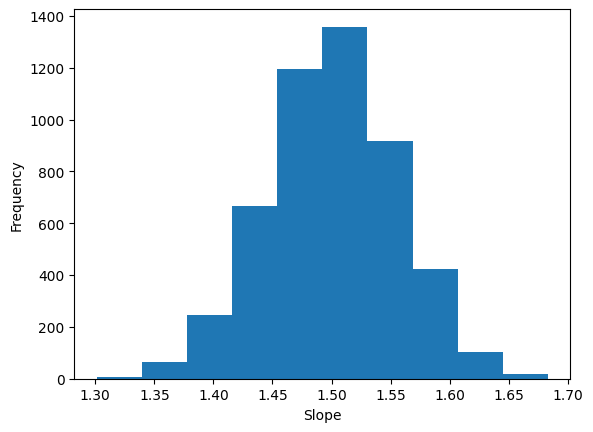

In [22]:
plt.hist(slopes)
plt.xlabel('Slope')
plt.ylabel('Frequency')
plt.show()

Let's use the sampling distribution to approximate the probability of observing a sample slope larger than 1.65. This can be calculated by looking at the proportion of simulated values larger than 1.65.

In [25]:
np.mean(np.array(slopes) > 1.65)

np.float64(0.0032)

If we assume that the true slope is 1.65 or smaller, the simulated probability of observing a sample slope greater than 1.65 is approximately 0.32%. Because this probability is very small, such an extreme slope would be unlikely under the null hypothesis ($H_0: \beta_1 \le 1.65$). Therefore, we have evidence to reject the null hypothesis that the true slope is less than or equal to 1.65.


## Part III: Big Data Examples & Rare Events

5. In the Group attribution bias, consider the example that an ML model is created to identify the most suitable candidates for a position with the OTP:

- If past hiring decisions favored a particular demographic group, the dataset will be in favor of that group more often.
- If certain groups were underrepresented in past applicant pools or hiring outcomes, the model will have less information about them.


The main problem is that the data used to train the model is not representative of the whole population and the unbiased truth.

To address this problem, we could consider collect a more representative data, remove proxy variables, and redefine the response variable, for example, reflect on the objective performance rather than historical hiring decisions.

6. One area this article focuses on was the surface water, utilizing big data to better understand water systems such as rainfall, rivers, groundwater, and floods. Researchers integrated vast datasets from satellites, weather stations, river level stations, and hydrological models to monitor and predict water availability and extreme events such as floods or droughts. These datasets, collected over long time spans and wide geographical areas, enable scientists to analyze water cycle patterns and improve predictive models.

However, different data sources may measure variables differently, which can introduce inconsistencies when datasets are combined. Missing observations from malfunctioning systems or incomplete historical records may also affect model accuracy, which all introduces bias.

7. One example I can think of is disease outbreaks. Large disease outbreaks or pandemics (Such as COVID-19 pandemic we experienced) are rare, but they can have massive impacts on public in many aspects.

## Part IV: Querying a database


8. First connect to the database.

In [6]:
import pandas as pd
import sqlite3

con = sqlite3.connect('lahman_1871-2022.sqlite')

get_schema = '''
        SELECT *
        FROM sqlite_schema
        WHERE type = "table";
        '''

schema_df2 = pd.read_sql(get_schema, con)
schema_df2

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


8. Returns all the teams that played in the year 2015 with all of the corresponding columns from the Teams table

In [9]:
pd.read_sql("SELECT * FROM Teams WHERE yearID = 2015;", con)

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET
5,2015,AL,HOU,HOU,W,2,162,81,86,76,...,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU
6,2015,AL,KCA,KCR,C,1,162,81,95,67,...,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
7,2015,AL,LAA,ANA,W,3,162,81,85,77,...,108,0.984,Los Angeles Angels of Anaheim,Angel Stadium of Anaheim,3012765,94,95,LAA,ANA,ANA
8,2015,AL,MIN,MIN,C,2,162,81,83,79,...,150,0.986,Minnesota Twins,Target Field,2220054,103,104,MIN,MIN,MIN
9,2015,AL,NYA,NYY,E,2,162,81,87,75,...,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA


9. Returns all of the players in the hall of fame, the year they were voted into the hall of fame, and their category

In [12]:
pd.read_sql("SELECT playerID, yearid, category FROM HallOfFame WHERE inducted = 'Y';", con)

,playerID,yearid,category
0,aaronha01,1982,Player
1,alexape01,1938,Player
2,alomaro01,2011,Player
3,alstowa01,1983,Manager
4,andersp01,2000,Manager
...,...,...,...
335,yastrca01,1989,Player
336,yawketo99,1980,Pioneer/Executive
337,youngcy01,1937,Player
338,youngro01,1972,Player
